# 04 — Multi-Task Neural Network
**ZivaBasa MVP (Kaggle-Data Phase)**

Builds the explainable multi-task deep learning architecture from the ChiedzaAI proposal:

```
Employment Input   Skills Input   Productivity Input
   (F_e dims)        (F_s dims)      (F_p dims)
      │                  │                │
Task Adapter        Task Adapter     Task Adapter      <- projects each dataset's
Dense(128, ReLU)     Dense(128, ReLU) Dense(128, ReLU)     own feature space into a
      │                  │                │                shared common latent space
      └──────────────────┼────────────────┘
                          ▼
      Shared Trunk: Dense(256, ReLU) → BatchNorm → Dropout(0.3)
                    → Dense(128, ReLU) → Dropout(0.3)
                          │
        ┌─────────────────┼─────────────────┐
        ▼                 ▼                 ▼
   Employment Head    Skills Head     Productivity Head
   Dense(64→32)       Dense(64→32)    Dense(64→32)
        │                 │                 │
   Output(1)          Output(1)         Output(1)
   (sigmoid)          (sigmoid)         (linear)
```

### Why task-specific input adapters?

The three datasets are **different populations with different schemas** (documented in the
README's Known Limitations). A single shared trunk normally expects one common input vector.
The adapters solve this: each task's raw feature vector is projected into a common latent
dimension *before* hitting the shared trunk, so the trunk still learns a genuinely shared
representation without requiring the datasets to be row-aligned or same-shaped.

### Why a custom training loop instead of `model.fit()`?

Because the three datasets aren't row-aligned, there's no single `(X, [y1, y2, y3])` tensor to
call `.fit()` on. Each training step draws an independent mini-batch from each task's dataset,
runs it through that task's path (adapter → shared trunk → head), and combines the three losses
before a single backward pass — so the shared trunk gets gradient signal from all three tasks
every step, exactly as a shared-trunk multi-task model should.

**Input:** `data/processed/{employment,skills,productivity}_features.parquet`
**Output:** `models/multitask_model/` (weights) + MLflow run with per-task metrics


In [1]:
# --- Setup ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
tf.random.set_seed(42)
np.random.seed(42)

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models/multitask_model"
os.makedirs(MODELS_DIR, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow: 2.16.1
GPU available: False


### A note on MLflow

MLflow logging here is **optional and defensive**: if `import mlflow` fails (a broken local
install is a common issue — mlflow depends on `pkg_resources`, part of `setuptools`, which is
sometimes missing in newer Python/conda environments) or `mlflow.start_run()` throws for any
other reason, training still runs to completion. You just won't get the MLflow run history.

If you hit `ModuleNotFoundError: No module named 'pkg_resources'`, run:
```bash
pip install setuptools
```
in the environment this notebook is using. If that doesn't fix it, pinning the exact version
from `requirements.txt` (`pip install mlflow==2.14.1`) is the more durable fix — mlflow's import
chain has been fragile across recent Python versions.


In [2]:
try:
    import mlflow
    mlflow.set_tracking_uri("../mlruns")
    mlflow.set_experiment("zivabasa_mvp_multitask_nn")
    MLFLOW_AVAILABLE = True
    print("MLflow available — runs will be logged to ../mlruns")
except Exception as e:
    MLFLOW_AVAILABLE = False
    print(f"MLflow unavailable ({type(e).__name__}: {e}) — continuing WITHOUT run logging.")
    print("See the note above for how to fix your mlflow install; training below is unaffected.")

import contextlib

def mlflow_run_ctx(run_name):
    """Returns a real mlflow run context if available, else a harmless no-op context."""
    if MLFLOW_AVAILABLE:
        return mlflow.start_run(run_name=run_name)
    return contextlib.nullcontext()

def mlflow_log_param(key, value):
    if MLFLOW_AVAILABLE:
        try:
            mlflow.log_param(key, value)
        except Exception as e:
            print(f"[mlflow] log_param failed, continuing without it: {e}")

def mlflow_log_metric(key, value, step=None):
    if MLFLOW_AVAILABLE:
        try:
            mlflow.log_metric(key, value, step=step)
        except Exception as e:
            print(f"[mlflow] log_metric failed, continuing without it: {e}")


MLflow unavailable (ModuleNotFoundError: No module named 'pkg_resources') — continuing WITHOUT run logging.
See the note above for how to fix your mlflow install; training below is unaffected.


## 1. Load Processed Features & Build Per-Task Splits

Same target/drop-column configuration as `03_baseline_models.ipynb` — kept consistent so the
neural network results are directly comparable to the baselines.


In [3]:
def load_features(name):
    path = os.path.join(PROCESSED_DIR, f"{name}_features.parquet")
    if not os.path.exists(path):
        print(f"[MISSING] {path} — run 02_feature_engineering.ipynb first.")
        return None
    df = pd.read_parquet(path)
    print(f"[{name}] loaded {df.shape[0]:,} rows x {df.shape[1]} cols")
    return df

TASK_CONFIG = {
    "employment": {
        "df": load_features("employment"),
        "target": "target_high_automation_risk",
        "task_type": "classification",
        "drop_cols": ["target_high_automation_risk", "automation_risk", "automation_exposure_index"],
        "loss_weight": 1.0,
    },
    "skills": {
        "df": load_features("skills"),
        "target": "target_attrition",
        "task_type": "classification",
        "drop_cols": ["target_attrition"],
        "loss_weight": 1.0,
    },
    "productivity": {
        "df": load_features("productivity"),
        "target": "target_ai_adoption",
        "task_type": "regression",
        "drop_cols": ["target_ai_adoption", "ai_adoption_level", "ai_adoption_index"],
        "loss_weight": 1.0,   # regression losses (MSE) live on a different scale than BCE —
                               # revisit this weight once you see the loss curves in Section 6
    },
}


[employment] loaded 3,000 rows x 28 cols
[skills] loaded 1,470 rows x 20 cols
[productivity] loaded 15,000 rows x 11 cols


In [4]:
splits = {}

for name, cfg in TASK_CONFIG.items():
    df = cfg["df"]
    if df is None or cfg["target"] not in df.columns:
        print(f"[{name}] skipped — missing data or target.")
        continue

    drop_cols = [c for c in cfg["drop_cols"] if c in df.columns]
    X = df.drop(columns=drop_cols).select_dtypes(include=[np.number]).astype("float32")
    y = df[cfg["target"]].astype("float32")

    stratify = y if cfg["task_type"] == "classification" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=stratify
    )
    # further split train -> train/val for early stopping
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42,
        stratify=y_train if cfg["task_type"] == "classification" else None
    )

    splits[name] = {
        "X_train": X_train.values, "y_train": y_train.values,
        "X_val": X_val.values, "y_val": y_val.values,
        "X_test": X_test.values, "y_test": y_test.values,
        "feature_names": list(X.columns),
        "input_dim": X.shape[1],
    }
    print(f"[{name}] train={len(X_train):,} val={len(X_val):,} test={len(X_test):,} "
          f"features={X.shape[1]}")


[employment] skipped — missing data or target.
[skills] train=999 val=177 test=294 features=8
[productivity] train=10,200 val=1,800 test=3,000 features=1


## 2. Build the Shared-Trunk Multi-Task Model

Shared layers are instantiated **once** and reused across all three task paths — that's what
makes the trunk genuinely shared in Keras (same layer object called on different inputs shares
weights). Each task gets its own adapter (heterogeneous input dim → common latent dim) and its
own head (shared representation → task-specific output).


In [5]:
LATENT_DIM = 64      # common dimension after task-specific adapters
TRUNK_DIM_1 = 256
TRUNK_DIM_2 = 128
DROPOUT_RATE = 0.3

# --- Shared trunk layers (instantiated once, reused for every task) ---
shared_dense1 = layers.Dense(TRUNK_DIM_1, activation="relu", name="shared_dense1")
shared_bn1 = layers.BatchNormalization(name="shared_bn1")
shared_dropout1 = layers.Dropout(DROPOUT_RATE, name="shared_dropout1")
shared_dense2 = layers.Dense(TRUNK_DIM_2, activation="relu", name="shared_dense2")
shared_dropout2 = layers.Dropout(DROPOUT_RATE, name="shared_dropout2")

def shared_trunk(x, training=False):
    x = shared_dense1(x)
    x = shared_bn1(x, training=training)
    x = shared_dropout1(x, training=training)
    x = shared_dense2(x)
    x = shared_dropout2(x, training=training)
    return x

def build_task_model(task_name, input_dim, task_type):
    inputs = layers.Input(shape=(input_dim,), name=f"{task_name}_input")

    # Task-specific adapter: projects this dataset's own feature space into the common latent dim
    adapter = layers.Dense(LATENT_DIM, activation="relu", name=f"{task_name}_adapter")(inputs)

    # Shared trunk (weights shared across all three task models)
    trunk_out = shared_trunk(adapter, training=True)

    # Task-specific head
    head = layers.Dense(64, activation="relu", name=f"{task_name}_head_dense64")(trunk_out)
    head = layers.Dense(32, activation="relu", name=f"{task_name}_head_dense32")(head)

    if task_type == "classification":
        outputs = layers.Dense(1, activation="sigmoid", name=f"{task_name}_output")(head)
    else:
        outputs = layers.Dense(1, activation="linear", name=f"{task_name}_output")(head)

    return Model(inputs=inputs, outputs=outputs, name=f"{task_name}_model")

task_models = {
    name: build_task_model(name, splits[name]["input_dim"], TASK_CONFIG[name]["task_type"])
    for name in splits
}

for name, m in task_models.items():
    print(f"=== {name} model ===")
    m.summary()
    print()


=== skills model ===


Model: "skills_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ skills_input (InputLayer)       │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skills_adapter (Dense)          │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense1 (Dense)           │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_bn1 (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dropout1 (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense2 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dropout2 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skills_head_dense64 (Dense)     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skills_head_dense32 (Dense)     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ skills_output (Dense)           │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,505 (240.25 KB)

 Trainable params: 60,993 (238.25 KB)

...

Model: "productivity_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ productivity_input (InputLayer) │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ productivity_adapter (Dense)    │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense1 (Dense)           │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_bn1 (BatchNormalization) │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dropout1 (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dense2 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ shared_dropout2 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ productivity_head_dense64       │ (None, 64)             │         8,256 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ productivity_head_dense32       │ (None, 32)             │         2,080 │
│ (Dense)                         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ productivity_output (Dense)     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,057 (238.50 KB)

 Trainable params: 60,545 (236.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [6]:
# --- Deduplicate trainable variables across the three models ---
# Shared layers appear in all three models' .trainable_variables, so we dedupe by variable id
# to avoid applying gradients to the shared trunk three times per step.
def collect_unique_trainable_vars(models_dict):
    seen = {}
    for m in models_dict.values():
        for v in m.trainable_variables:
            seen[id(v)] = v
    return list(seen.values())

all_trainable_vars = collect_unique_trainable_vars(task_models)
print(f"Unique trainable variables across all task models: {len(all_trainable_vars)}")


Unique trainable variables across all task models: 22


## 3. Losses, Optimizer, and Manual Callbacks

BinaryCrossentropy for the two classification heads, MSE for the regression head. Optimizer is
Adam with a manually-managed learning rate (acts as our `ReduceLROnPlateau`). Early stopping and
checkpointing are implemented manually since this is a custom training loop, not `model.fit()`.


In [7]:
loss_fns = {
    "employment": tf.keras.losses.BinaryCrossentropy(),
    "skills": tf.keras.losses.BinaryCrossentropy(),
    "productivity": tf.keras.losses.MeanSquaredError(),
}

initial_lr = 1e-3

# NOTE: newer Keras (3.x, bundled with TF >= 2.16) no longer accepts a raw tf.Variable for
# `learning_rate` -- the optimizer creates its own internal LR variable instead. We drive our
# manual ReduceLROnPlateau by assigning to that internal variable directly.
optimizer = tf.keras.optimizers.Adam(learning_rate=initial_lr)
lr_var = optimizer.learning_rate

BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 10          # early stopping patience (epochs)
LR_PATIENCE = 5         # ReduceLROnPlateau-style patience
LR_FACTOR = 0.5
MIN_LR = 1e-6

def make_batched_dataset(X, y, batch_size, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    return ds.repeat().batch(batch_size)

train_iters = {
    name: iter(make_batched_dataset(s["X_train"], s["y_train"], BATCH_SIZE))
    for name, s in splits.items()
}

steps_per_epoch = max(
    int(np.ceil(len(s["X_train"]) / BATCH_SIZE)) for s in splits.values()
)
print(f"Steps per epoch: {steps_per_epoch}")


Steps per epoch: 319


## 4. Custom Training Step

One gradient step per call: draw a batch from each task's dataset independently, forward each
through its own path (adapter → shared trunk → head), compute each task's loss, combine with the
configured task weights, and apply a single set of gradients to the deduped variable list.


In [8]:
@tf.function
def train_step(batches):
    with tf.GradientTape() as tape:
        total_loss = 0.0
        task_losses = {}
        for name, (X_batch, y_batch) in batches.items():
            y_pred = task_models[name](X_batch, training=True)
            y_pred = tf.squeeze(y_pred, axis=-1)
            loss = loss_fns[name](y_batch, y_pred)
            task_losses[name] = loss
            total_loss += TASK_CONFIG[name]["loss_weight"] * loss

    grads = tape.gradient(total_loss, all_trainable_vars)
    optimizer.apply_gradients(zip(grads, all_trainable_vars))
    return total_loss, task_losses

def validation_pass():
    val_losses = {}
    for name, s in splits.items():
        y_pred = task_models[name](s["X_val"], training=False)
        y_pred = tf.squeeze(y_pred, axis=-1)
        val_losses[name] = float(loss_fns[name](s["y_val"], y_pred))
    return val_losses


## 5. Training Loop

Runs until `PATIENCE` epochs pass with no improvement in the weighted total validation loss, or
`EPOCHS` is reached. Best weights (by val loss) are checkpointed in memory and restored at the end.


In [9]:
history = {"train_total": [], "val_total": []}
for name in splits:
    history[f"val_{name}"] = []

best_val_total = np.inf
best_weights = None
epochs_no_improve = 0
lr_epochs_no_improve = 0

with mlflow_run_ctx("multitask_shared_trunk"):
    mlflow_log_param("latent_dim", LATENT_DIM)
    mlflow_log_param("trunk_dim_1", TRUNK_DIM_1)
    mlflow_log_param("trunk_dim_2", TRUNK_DIM_2)
    mlflow_log_param("dropout_rate", DROPOUT_RATE)
    mlflow_log_param("batch_size", BATCH_SIZE)
    mlflow_log_param("initial_lr", initial_lr)
    for name, cfg in TASK_CONFIG.items():
        mlflow_log_param(f"loss_weight_{name}", cfg["loss_weight"])

    for epoch in range(EPOCHS):
        epoch_train_loss = 0.0
        for step in range(steps_per_epoch):
            batches = {name: next(train_iters[name]) for name in splits}
            total_loss, task_losses = train_step(batches)
            epoch_train_loss += float(total_loss)
        epoch_train_loss /= steps_per_epoch

        val_losses = validation_pass()
        val_total = sum(TASK_CONFIG[name]["loss_weight"] * v for name, v in val_losses.items())

        history["train_total"].append(epoch_train_loss)
        history["val_total"].append(val_total)
        for name, v in val_losses.items():
            history[f"val_{name}"].append(v)

        mlflow_log_metric("train_total_loss", epoch_train_loss, step=epoch)
        mlflow_log_metric("val_total_loss", val_total, step=epoch)
        for name, v in val_losses.items():
            mlflow_log_metric(f"val_{name}_loss", v, step=epoch)
        mlflow_log_metric("learning_rate", float(lr_var.numpy()), step=epoch)

        improved = val_total < best_val_total - 1e-5
        if improved:
            best_val_total = val_total
            best_weights = {name: m.get_weights() for name, m in task_models.items()}
            epochs_no_improve = 0
            lr_epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            lr_epochs_no_improve += 1

        # ReduceLROnPlateau-style manual LR decay
        if lr_epochs_no_improve >= LR_PATIENCE and lr_var.numpy() > MIN_LR:
            new_lr = max(lr_var.numpy() * LR_FACTOR, MIN_LR)
            lr_var.assign(new_lr)
            lr_epochs_no_improve = 0
            print(f"  -> LR reduced to {new_lr:.2e}")

        if epoch % 5 == 0 or improved:
            print(f"Epoch {epoch:3d} | train_loss={epoch_train_loss:.4f} | "
                  f"val_loss={val_total:.4f}{' *' if improved else ''}")

        # Early stopping
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
            break

    # Restore best weights
    for name, m in task_models.items():
        m.set_weights(best_weights[name])
    print(f"\nBest val_total_loss: {best_val_total:.4f} — best weights restored.")

    mlflow_log_metric("best_val_total_loss", best_val_total)


Epoch   0 | train_loss=1.4392 | val_loss=1.4756 *
  -> LR reduced to 5.00e-04
Epoch   5 | train_loss=1.2721 | val_loss=1.8077
  -> LR reduced to 2.50e-04
Epoch  10 | train_loss=1.1766 | val_loss=2.0994

Early stopping at epoch 10 (no improvement for 10 epochs).

Best val_total_loss: 1.4756 — best weights restored.


## 6. Training Curves


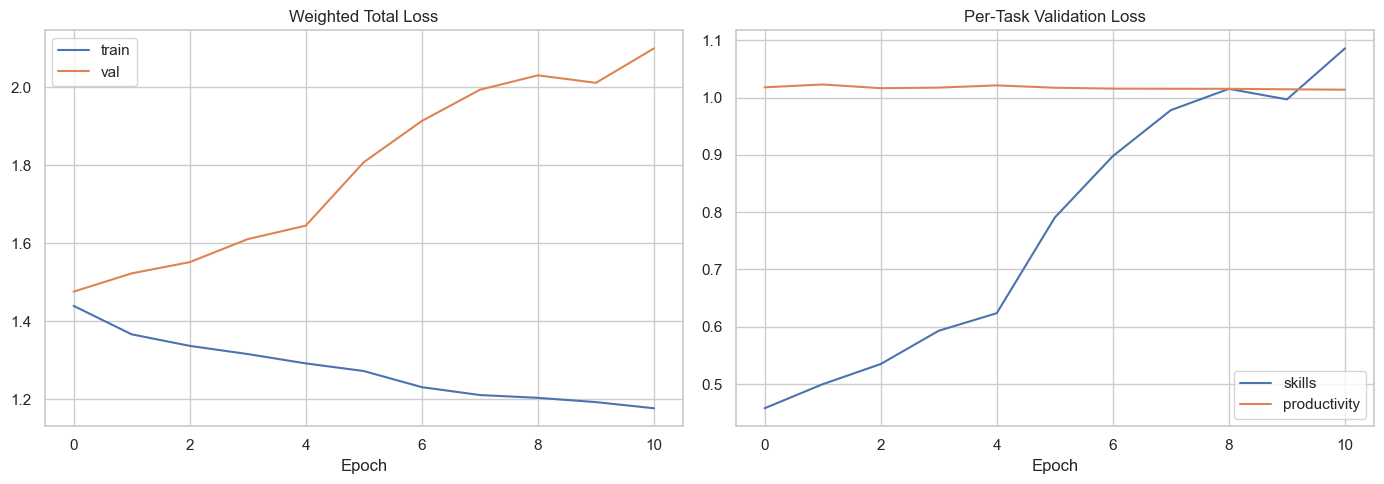

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["val_total"], label="val")
axes[0].set_title("Weighted Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

for name in splits:
    axes[1].plot(history[f"val_{name}"], label=name)
axes[1].set_title("Per-Task Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Evaluation on Held-Out Test Sets

Same metric set as the baselines in notebook 03, so the comparison is apples-to-apples.


In [11]:
nn_results = []

for name, s in splits.items():
    task_type = TASK_CONFIG[name]["task_type"]
    y_pred_raw = task_models[name](s["X_test"], training=False).numpy().squeeze()
    y_test = s["y_test"]

    if task_type == "classification":
        y_pred = (y_pred_raw > 0.5).astype(int)
        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        }
        try:
            metrics["roc_auc"] = roc_auc_score(y_test, y_pred_raw)
        except ValueError:
            metrics["roc_auc"] = np.nan
    else:
        metrics = {
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred_raw)),
            "mae": mean_absolute_error(y_test, y_pred_raw),
            "r2": r2_score(y_test, y_pred_raw),
        }

    nn_results.append({"task_head": name, "model": "multitask_nn", **metrics})

nn_results_df = pd.DataFrame(nn_results)
nn_results_df


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,skills,multitask_nn,0.789116,0.285714,0.212766,0.243902,0.625118,NaN,NaN,NaN
1,productivity,multitask_nn,NaN,NaN,NaN,NaN,NaN,0.998642,0.866287,-0.010936


## 8. Compare Against Baselines

Loads `models/baseline_results.csv` from notebook 03 and lines it up against the multi-task NN,
per task head. This is the comparison table your evaluation section needs — does the added
complexity of the shared-trunk deep model actually buy anything over the classical baselines?


In [12]:
baseline_path = "../models/baseline_results.csv"
if os.path.exists(baseline_path):
    baseline_df = pd.read_csv(baseline_path)
    combined = pd.concat([baseline_df, nn_results_df], ignore_index=True)
    for task_name in TASK_CONFIG:
        task_view = combined[combined["task_head"] == task_name]
        if task_view.empty:
            continue
        print(f"=== {task_name.upper()} — Baselines vs. Multi-Task NN ===")
        sort_col = "roc_auc" if "roc_auc" in task_view.columns and task_view["roc_auc"].notna().any() else "r2"
        display(task_view.sort_values(sort_col, ascending=False).reset_index(drop=True))
        print()
else:
    print("[MISSING] ../models/baseline_results.csv — run 03_baseline_models.ipynb first to compare.")


=== SKILLS — Baselines vs. Multi-Task NN ===


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,skills,logistic_regression,0.826531,0.250000,0.042553,0.072727,0.680076,NaN,NaN,NaN
1,skills,random_forest,0.823129,0.368421,0.148936,0.212121,0.646524,NaN,NaN,NaN
2,skills,multitask_nn,0.789116,0.285714,0.212766,0.243902,0.625118,NaN,NaN,NaN
3,skills,gradient_boosting,0.795918,0.303030,0.212766,0.250000,0.598717,NaN,NaN,NaN
4,skills,decision_tree,0.772109,0.166667,0.106383,0.129870,0.500775,NaN,NaN,NaN



=== PRODUCTIVITY — Baselines vs. Multi-Task NN ===


,task_head,model,accuracy,precision,recall,f1,roc_auc,rmse,mae,r2
0,productivity,linear_regression,NaN,NaN,NaN,NaN,NaN,0.993797,0.863194,-0.001151
1,productivity,random_forest,NaN,NaN,NaN,NaN,NaN,0.997211,0.865452,-0.008041
2,productivity,multitask_nn,NaN,NaN,NaN,NaN,NaN,0.998642,0.866287,-0.010936
3,productivity,gradient_boosting,NaN,NaN,NaN,NaN,NaN,0.998659,0.866095,-0.010970
4,productivity,decision_tree,NaN,NaN,NaN,NaN,NaN,1.006364,0.869790,-0.026630


## 9. Save Model Weights + Architecture


In [13]:
for name, m in task_models.items():
    save_path = os.path.join(MODELS_DIR, f"{name}_model.keras")
    m.save(save_path)
    print(f"[{name}] saved -> {save_path}")

nn_results_path = os.path.join(MODELS_DIR, "multitask_nn_results.csv")
nn_results_df.to_csv(nn_results_path, index=False)
print(f"\nResults saved -> {nn_results_path}")

print("""
Note: Each .keras file contains that task's full path (adapter -> shared trunk -> head).
Because the shared trunk layers are the SAME layer objects across all three models, their
weights are identical across all three saved files -- this is expected, not duplication of
distinct trunks. Loading any one of them gives you a shared-trunk snapshot.
""")


[skills] saved -> ../models/multitask_model\skills_model.keras
[productivity] saved -> ../models/multitask_model\productivity_model.keras

Results saved -> ../models/multitask_model\multitask_nn_results.csv

Note: Each .keras file contains that task's full path (adapter -> shared trunk -> head).
Because the shared trunk layers are the SAME layer objects across all three models, their
weights are identical across all three saved files -- this is expected, not duplication of
distinct trunks. Loading any one of them gives you a shared-trunk snapshot.



## 10. Summary — Carry Forward to Notebook 05

- [ ] Multi-task NN metrics compared against baselines per task head (Section 8) — note where it
      wins/loses, that's a real result to report either way
- [ ] Training curves (Section 6) checked for signs of overfitting (train/val divergence) or an
      undertrained task (val loss still falling at early-stopping cutoff)
- [ ] `loss_weight` per task (Section 1) revisited if one task's loss dominates the shared
      gradient — regression (MSE) and classification (BCE) losses live on different scales
- [ ] Saved model paths noted for `05_shap_explainability.ipynb` — SHAP will need
      `DeepExplainer` run separately per task model
